
# Operasi Matriks dan Turunan Manual

**Tujuan:** Membangun intuisi bahwa *neural network* pada dasarnya adalah tumpukan (*layer*) operasi
matriks, dan bahwa *backpropagation* tidak lain adalah aplikasi berulang dari **aturan rantai (chain rule)**
dari kalkulus.

Kedua ide ini adalah fondasi untuk memahami notasi yang sering muncul pada arsitektur seperti LSTM, misalnya:

$$
f_t = \sigma\big(W_f [h_{t-1}, x_t] + b_f\big)
$$

Notasi di atas sebenarnya hanya menggabungkan dua operasi yang akan kita bedah manual di notebook ini:

1. **Perkalian matriks** — $W_f [h_{t-1}, x_t]$ adalah perkalian matriks bobot $W_f$ dengan vektor gabungan
   (*concatenation*) dari hidden state sebelumnya $h_{t-1}$ dan input $x_t$.
2. **Turunan / gradien** — saat melatih jaringan ini, kita perlu menghitung turunan dari fungsi loss
   terhadap setiap bobot, yang dilakukan lewat *chain rule* — persis seperti yang akan kita hitung manual
   pada contoh $\frac{d}{dx}\sin(x^2)$ di bagian akhir notebook.

**Struktur notebook:**

- **Bagian A — Perkalian Matriks**
  - A.1 Implementasi manual dengan tiga `for`-loop bersarang
  - A.2 Verifikasi kebenaran hasil (manual vs NumPy vs PyTorch)
  - A.3 Perbandingan waktu eksekusi pada matriks 100×100
- **Bagian B — Turunan Manual vs Autograd**
  - B.1 Turunan $\frac{d}{dx}\sin(x^2)$ secara manual (chain rule)
  - B.2 Verifikasi dengan `torch.autograd`
- **Bagian C — Kesimpulan & Kaitan dengan Neural Network**


In [1]:

# Import library yang dibutuhkan di sepanjang notebook
import time
import math
import random

import numpy as np
import torch

# Untuk hasil yang bisa direproduksi
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("NumPy version :", np.__version__)
print("PyTorch version:", torch.__version__)


NumPy version : 2.5.1
PyTorch version: 2.13.0+cpu



## Bagian A — Perkalian Matriks

### Teori singkat

Diberikan matriks $A$ berukuran $(m \times n)$ dan matriks $B$ berukuran $(n \times p)$, hasil perkalian
$C = A B$ berukuran $(m \times p)$, dengan setiap elemen didefinisikan sebagai:

$$
C_{ij} = \sum_{k=1}^{n} A_{ik} \, B_{kj}
$$

Artinya, elemen baris ke-$i$ kolom ke-$j$ dari $C$ adalah **hasil kali titik (dot product)** antara baris
ke-$i$ dari $A$ dan kolom ke-$j$ dari $B$.

Dalam konteks neural network, operasi ini adalah jantung dari setiap *layer* — misalnya pada
$W_f [h_{t-1}, x_t]$, matriks bobot $W_f$ "dikalikan" dengan vektor input untuk menghasilkan kombinasi
linear dari semua fitur input, sebelum dilewatkan ke fungsi aktivasi non-linear $\sigma(\cdot)$.

Secara komputasi, definisi $C_{ij} = \sum_k A_{ik} B_{kj}$ di atas persis diterjemahkan menjadi **tiga
loop bersarang**: loop atas baris $i$, loop atas kolom $j$, dan loop atas indeks penjumlahan $k$.


In [2]:

def matmul_manual(A, B):
    '''
    Perkalian matriks murni Python (tanpa NumPy/PyTorch), tiga for-loop bersarang.

    Parameters
    ----------
    A : list[list[float]]  -> matriks berukuran (m x n)
    B : list[list[float]]  -> matriks berukuran (n x p)

    Returns
    -------
    C : list[list[float]]  -> hasil A @ B, berukuran (m x p)
    '''
    m = len(A)          # jumlah baris A
    n = len(A[0])        # jumlah kolom A = jumlah baris B
    n_b = len(B)
    p = len(B[0])        # jumlah kolom B

    if n != n_b:
        raise ValueError(
            f"Dimensi tidak cocok: A adalah ({m}x{n}), B adalah ({n_b}x{p}). "
            f"Jumlah kolom A harus sama dengan jumlah baris B."
        )

    # Inisialisasi matriks hasil C berukuran (m x p) dengan nol
    C = [[0.0 for _ in range(p)] for _ in range(m)]

    # Loop 1: iterasi baris matriks A -> menentukan baris hasil C
    for i in range(m):
        # Loop 2: iterasi kolom matriks B -> menentukan kolom hasil C
        for j in range(p):
            total = 0.0
            # Loop 3: iterasi indeks penjumlahan (dot product baris A[i] dan kolom B[:,j])
            for k in range(n):
                total += A[i][k] * B[k][j]
            C[i][j] = total

    return C



### A.1 Uji coba dengan matriks kecil

Sebelum mengukur performa pada matriks besar, kita pastikan dulu fungsi `matmul_manual` benar pada
contoh kecil yang bisa dihitung dengan tangan.


In [3]:

# Contoh kecil: A berukuran (2x3), B berukuran (3x2)
A_small = [
    [1, 2, 3],
    [4, 5, 6],
]
B_small = [
    [7, 8],
    [9, 10],
    [11, 12],
]

C_manual_small = matmul_manual(A_small, B_small)
C_numpy_small = (np.array(A_small) @ np.array(B_small)).tolist()

print("Hasil manual :", C_manual_small)
print("Hasil NumPy  :", C_numpy_small)
print("Sama persis? :", C_manual_small == C_numpy_small)


Hasil manual : [[58.0, 64.0], [139.0, 154.0]]
Hasil NumPy  : [[58, 64], [139, 154]]
Sama persis? : True



### A.2 & A.3 Perbandingan pada matriks 100×100: kebenaran hasil dan waktu eksekusi

Sekarang kita bandingkan tiga pendekatan pada matriks berukuran $(100 \times 100) \times (100 \times 100)$:

1. **Manual** — fungsi `matmul_manual` dengan tiga `for`-loop Python murni.
2. **NumPy** — operator `@` (setara `numpy.dot` untuk array 2D), yang di baliknya memanggil rutin BLAS
   teroptimasi (biasanya dalam bahasa C/Fortran, dengan vektorisasi SIMD).
3. **PyTorch** — `torch.matmul`, yang juga memanggil backend teroptimasi (dan bisa berjalan di GPU jika
   tersedia).

Kita mengharapkan **hasil numerik yang sama** (dengan toleransi kecil karena floating-point), tetapi
**waktu eksekusi yang jauh berbeda** — inilah alasan mengapa library seperti NumPy dan PyTorch selalu
dipakai untuk komputasi neural network, bukan loop Python murni.


In [4]:

# Bangkitkan matriks acak 100x100
N = 100
A_np = np.random.rand(N, N)
B_np = np.random.rand(N, N)

# Versi list-of-lists untuk fungsi manual
A_list = A_np.tolist()
B_list = B_np.tolist()

# Versi tensor PyTorch
A_torch = torch.tensor(A_np, dtype=torch.float64)
B_torch = torch.tensor(B_np, dtype=torch.float64)

print(f"Ukuran matriks: {N} x {N}")


Ukuran matriks: 100 x 100


In [5]:

# --- 1) Perkalian manual (tiga for-loop) ---
start = time.perf_counter()
C_manual = matmul_manual(A_list, B_list)
time_manual = time.perf_counter() - start

C_manual_np = np.array(C_manual)  # untuk memudahkan perbandingan numerik

print(f"Waktu manual (Python murni) : {time_manual:.4f} detik")


Waktu manual (Python murni) : 0.1277 detik


In [6]:

# --- 2) Perkalian dengan NumPy (operator @, setara numpy.dot untuk array 2D) ---
start = time.perf_counter()
C_numpy = A_np @ B_np
# Alternatif yang setara: C_numpy = np.dot(A_np, B_np)
time_numpy = time.perf_counter() - start

print(f"Waktu NumPy (@ / numpy.dot) : {time_numpy:.6f} detik")


Waktu NumPy (@ / numpy.dot) : 0.016413 detik


In [7]:

# --- 3) Perkalian dengan PyTorch (torch.matmul) ---
start = time.perf_counter()
C_torch = torch.matmul(A_torch, B_torch)
time_torch = time.perf_counter() - start

print(f"Waktu PyTorch (torch.matmul): {time_torch:.6f} detik")


Waktu PyTorch (torch.matmul): 0.031723 detik



### Verifikasi kebenaran hasil

Kita bandingkan ketiga hasil menggunakan `numpy.allclose`, yang mentoleransi selisih kecil akibat
pembulatan *floating-point* (bukan `==` langsung, karena urutan operasi penjumlahan floating-point yang
berbeda antar implementasi bisa menghasilkan selisih di digit desimal terakhir).


In [8]:

C_torch_np = C_torch.numpy()

close_manual_numpy = np.allclose(C_manual_np, C_numpy)
close_numpy_torch = np.allclose(C_numpy, C_torch_np)
close_manual_torch = np.allclose(C_manual_np, C_torch_np)

print("Manual vs NumPy  sama (allclose)? :", close_manual_numpy)
print("NumPy  vs PyTorch sama (allclose)? :", close_numpy_torch)
print("Manual vs PyTorch sama (allclose)? :", close_manual_torch)

max_diff = np.max(np.abs(C_manual_np - C_numpy))
print(f"\nSelisih absolut maksimum (manual vs NumPy): {max_diff:.2e}")


Manual vs NumPy  sama (allclose)? : True
NumPy  vs PyTorch sama (allclose)? : True
Manual vs PyTorch sama (allclose)? : True

Selisih absolut maksimum (manual vs NumPy): 1.07e-14


In [9]:

# Ringkasan perbandingan waktu eksekusi
print("=" * 55)
print(f"{'Metode':<25}{'Waktu (detik)':>20}")
print("=" * 55)
print(f"{'Manual (3 for-loop)':<25}{time_manual:>20.6f}")
print(f"{'NumPy (@)':<25}{time_numpy:>20.6f}")
print(f"{'PyTorch (matmul)':<25}{time_torch:>20.6f}")
print("=" * 55)

if time_numpy > 0:
    print(f"\nNumPy lebih cepat {time_manual / time_numpy:,.0f}x dibanding manual")
if time_torch > 0:
    print(f"PyTorch lebih cepat {time_manual / time_torch:,.0f}x dibanding manual")


Metode                          Waktu (detik)
Manual (3 for-loop)                  0.127694
NumPy (@)                            0.016413
PyTorch (matmul)                     0.031723

NumPy lebih cepat 8x dibanding manual
PyTorch lebih cepat 4x dibanding manual



> **Catatan interpretasi:** Perbedaan kecepatan yang sangat besar (biasanya ratusan hingga ribuan kali
> lipat) bukan karena NumPy/PyTorch "curang", melainkan karena keduanya memanggil rutin **BLAS**
> (Basic Linear Algebra Subprograms) yang ditulis dalam C/Fortran, memanfaatkan vektorisasi CPU (SIMD),
> pengaturan memori cache-friendly, dan (untuk PyTorch) berpotensi memanfaatkan GPU. Inilah sebabnya
> semua framework deep learning dibangun di atas operasi matriks yang sudah dioptimasi, bukan loop
> Python murni — karena satu forward pass pada neural network bisa melibatkan jutaan hingga miliaran
> perkalian semacam ini.



## Bagian B — Turunan Manual vs `torch.autograd`

### Teori singkat: Chain Rule

*Backpropagation* pada neural network pada dasarnya adalah penerapan berulang **aturan rantai (chain
rule)**: jika $y = f(u)$ dan $u = g(x)$, maka:

$$
\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}
$$

Kita akan menerapkan aturan ini pada fungsi komposit:

$$
y = \sin(x^2)
$$

**Langkah turunan manual:**

Misalkan $u = x^2$, sehingga $y = \sin(u)$.

1. Turunan bagian luar terhadap $u$: $\dfrac{dy}{du} = \cos(u) = \cos(x^2)$
2. Turunan bagian dalam terhadap $x$: $\dfrac{du}{dx} = 2x$
3. Gabungkan dengan chain rule:

$$
\frac{dy}{dx} = \cos(x^2) \cdot 2x = 2x\cos(x^2)
$$

Inilah, pada level konseptual, persis apa yang dilakukan `torch.autograd` secara otomatis di balik layar
untuk setiap operasi pada graf komputasi — termasuk operasi matriks berlapis pada neural network
(misalnya menurunkan loss terhadap $W_f$ pada rumus $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$ juga
memakai chain rule yang sama, hanya dengan lebih banyak "lapisan").


In [10]:

def turunan_manual(x):
    '''
    Menghitung d/dx [sin(x^2)] = 2x * cos(x^2) secara manual (chain rule),
    menggunakan modul math bawaan Python (bukan NumPy/PyTorch).

    Parameters
    ----------
    x : float

    Returns
    -------
    float : nilai turunan di titik x
    '''
    return 2 * x * math.cos(x ** 2)


def fungsi_manual(x):
    '''y = sin(x^2), dihitung dengan math.sin murni Python.'''
    return math.sin(x ** 2)



### B.1 Hitung turunan manual pada beberapa titik uji


In [11]:

titik_uji = [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

print(f"{'x':>6} | {'y = sin(x^2)':>15} | {'dy/dx manual':>15}")
print("-" * 45)
for x_val in titik_uji:
    y_val = fungsi_manual(x_val)
    dy_val = turunan_manual(x_val)
    print(f"{x_val:>6.2f} | {y_val:>15.6f} | {dy_val:>15.6f}")


     x |    y = sin(x^2) |    dy/dx manual
---------------------------------------------
 -2.00 |       -0.756802 |        2.614574
 -1.00 |        0.841471 |       -1.080605
 -0.50 |        0.247404 |       -0.968912
  0.00 |        0.000000 |        0.000000
  0.50 |        0.247404 |        0.968912
  1.00 |        0.841471 |        1.080605
  1.50 |        0.778073 |       -1.884521
  2.00 |       -0.756802 |       -2.614574
  3.00 |        0.412118 |       -5.466782



### B.2 Verifikasi dengan `torch.autograd`

Sekarang kita hitung turunan yang sama menggunakan *automatic differentiation* PyTorch:

1. Buat tensor `x` dengan `requires_grad=True` agar PyTorch melacak operasi pada `x` di graf komputasi.
2. Hitung `y = torch.sin(x**2)`.
3. Panggil `y.backward()` untuk menjalankan backpropagation dan mengisi `x.grad` dengan $\dfrac{dy}{dx}$.
4. Bandingkan `x.grad` dengan hasil `turunan_manual(x)`.

Karena `backward()` pada PyTorch secara default hanya bekerja untuk output berbentuk skalar, kita hitung
untuk setiap titik uji satu per satu (masing-masing sebagai tensor skalar baru).


In [12]:

print(f"{'x':>6} | {'manual (2x cos(x^2))':>22} | {'autograd (x.grad)':>20} | {'selisih':>10}")
print("-" * 70)

hasil_manual_list = []
hasil_autograd_list = []

for x_val in titik_uji:
    # 1. Buat tensor x dengan requires_grad=True
    x = torch.tensor(x_val, dtype=torch.float64, requires_grad=True)

    # 2. Hitung y = sin(x^2)
    y = torch.sin(x ** 2)

    # 3. Backpropagation: menghitung dy/dx secara otomatis lewat chain rule internal PyTorch
    y.backward()

    # 4. Ambil gradien dari x.grad
    grad_autograd = x.grad.item()
    grad_manual = turunan_manual(x_val)

    hasil_manual_list.append(grad_manual)
    hasil_autograd_list.append(grad_autograd)

    selisih = abs(grad_manual - grad_autograd)
    print(f"{x_val:>6.2f} | {grad_manual:>22.10f} | {grad_autograd:>20.10f} | {selisih:>10.2e}")


     x |   manual (2x cos(x^2)) |    autograd (x.grad) |    selisih
----------------------------------------------------------------------
 -2.00 |           2.6145744835 |         2.6145744835 |   0.00e+00
 -1.00 |          -1.0806046117 |        -1.0806046117 |   0.00e+00
 -0.50 |          -0.9689124217 |        -0.9689124217 |   0.00e+00
  0.00 |           0.0000000000 |         0.0000000000 |   0.00e+00
  0.50 |           0.9689124217 |         0.9689124217 |   0.00e+00
  1.00 |           1.0806046117 |         1.0806046117 |   0.00e+00
  1.50 |          -1.8845208682 |        -1.8845208682 |   0.00e+00
  2.00 |          -2.6145744835 |        -2.6145744835 |   0.00e+00
  3.00 |          -5.4667815713 |        -5.4667815713 |   0.00e+00


In [13]:

# Verifikasi menyeluruh dengan np.allclose
sama_persis = np.allclose(hasil_manual_list, hasil_autograd_list)
print(f"\nApakah semua hasil manual dan autograd sama (dalam toleransi floating-point)? {sama_persis}")



Apakah semua hasil manual dan autograd sama (dalam toleransi floating-point)? True



### (Opsional) Visualisasi fungsi dan turunannya

Untuk memperkuat intuisi, kita plot $y = \sin(x^2)$ beserta turunannya $\dfrac{dy}{dx} = 2x\cos(x^2)$
pada rentang $x$ yang lebih rapat, menggunakan hasil `torch.autograd` (dihitung titik demi titik).


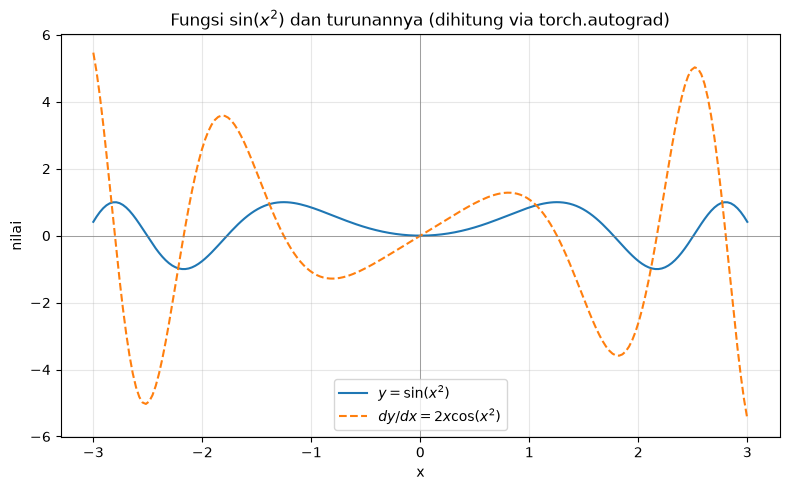

In [14]:

import matplotlib.pyplot as plt

x_range = np.linspace(-3, 3, 200)
y_vals = []
grad_vals = []

for xv in x_range:
    x_t = torch.tensor(float(xv), dtype=torch.float64, requires_grad=True)
    y_t = torch.sin(x_t ** 2)
    y_t.backward()
    y_vals.append(y_t.item())
    grad_vals.append(x_t.grad.item())

plt.figure(figsize=(8, 5))
plt.plot(x_range, y_vals, label=r"$y = \sin(x^2)$")
plt.plot(x_range, grad_vals, label=r"$dy/dx = 2x\cos(x^2)$", linestyle="--")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("x")
plt.ylabel("nilai")
plt.title(r"Fungsi $\sin(x^2)$ dan turunannya (dihitung via torch.autograd)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Bagian C — Kesimpulan & Kaitan dengan Neural Network

### Ringkasan hasil

1. **Perkalian matriks**: implementasi manual dengan tiga `for`-loop, NumPy (`@`), dan PyTorch
   (`torch.matmul`) menghasilkan nilai numerik yang **sama persis** (dalam toleransi floating-point),
   namun **waktu eksekusinya berbeda drastis** — NumPy dan PyTorch jauh lebih cepat karena memanfaatkan
   rutin BLAS teroptimasi, bukan interpreter Python murni.
2. **Turunan**: hasil perhitungan manual $\dfrac{d}{dx}\sin(x^2) = 2x\cos(x^2)$ melalui chain rule
   **identik** dengan hasil `x.grad` dari `torch.autograd`, yang menghitungnya secara otomatis dengan
   *reverse-mode automatic differentiation*.

### Mengapa ini penting untuk memahami neural network

Kembali ke notasi awal:

$$
f_t = \sigma\big(W_f [h_{t-1}, x_t] + b_f\big)
$$

- $W_f [h_{t-1}, x_t]$ adalah **perkalian matriks** — persis operasi yang kita bangun manual di Bagian A.
  Pada neural network sungguhan, operasi ini terjadi berulang-ulang di setiap *layer*, dengan matriks
  yang jauh lebih besar — sehingga penggunaan library teroptimasi (NumPy/PyTorch) menjadi krusial, bukan
  sekadar kenyamanan.
- Saat melatih model (mencari $W_f$ dan $b_f$ yang optimal), kita perlu menghitung turunan dari fungsi
  loss terhadap setiap parameter. Proses ini — **backpropagation** — adalah aplikasi chain rule secara
  berulang di sepanjang graf komputasi, persis seperti yang kita lakukan manual di Bagian B, hanya dengan
  lebih banyak fungsi yang dirangkai (perkalian matriks → penjumlahan bias → fungsi aktivasi $\sigma$ →
  ... → loss).

Dengan kata lain: **neural network = tumpukan operasi matriks**, dan **training neural network = chain
rule yang diterapkan otomatis oleh autograd** pada tumpukan operasi tersebut. `torch.autograd` pada
dasarnya melakukan hal yang sama seperti Bagian B di atas, tetapi untuk graf komputasi yang jauh lebih
besar dan kompleks — mencakup jutaan operasi matriks dan fungsi aktivasi sekaligus.
